# 03 — Model Training

Three classifiers per dataset — Logistic Regression, Random Forest, XGBoost —
tuned by cross-validated grid search on the training split only, then scored
once on the held-out test split. Twenty-seven models total, all persisted to
`models/` for the API to load.

The three are not interchangeable, and the spread between them is part of the
argument: Logistic Regression is intrinsically interpretable but limited to
additive effects, while the tree ensembles capture interactions at the cost of
becoming the black box that motivates SHAP and LIME in the first place. If the
ensembles were not meaningfully better, the honest recommendation would be to
deploy the transparent model and skip post-hoc explanation entirely.

In [1]:
import sys
import pathlib
import json
import time
import warnings

ROOT = pathlib.Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from xgboost import XGBClassifier

from xai import data, schema

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight"})
FIGURES = ROOT / "results" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = data.RANDOM_STATE
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print("scikit-learn CV:", CV)

scikit-learn CV: StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


## 3.1 Search strategy: GridSearchCV, and why not Optuna

**GridSearchCV with 5-fold stratified CV, scored on AUC-ROC.**

Optuna is the better tool when the search space is large or expensive. Neither
is true here: the largest dataset is 614 training rows and the largest grid is
48 candidates, so an exhaustive search finishes in seconds. Against that,
exhaustive search is *fully deterministic* — re-running this notebook a year
from now selects the identical hyperparameters, whereas a TPE sampler's path
depends on its seed and trial budget. For an academic artefact that has to
reproduce under `Restart & Run All`, determinism is worth more than sample
efficiency, and it saves a dependency.

**Why AUC-ROC is the selection metric:** most of the cohorts are
imbalanced, and AUC is threshold-independent, so selection is not entangled
with a 0.5 cut-off we have not yet justified clinically.

**Class imbalance** is handled inside the search rather than by resampling:
`class_weight` for the scikit-learn models and `scale_pos_weight` for XGBoost
are tuned as hyperparameters. SMOTE was rejected deliberately — synthesising
interpolated patients would put fabricated rows into a project whose premise is
that every row is real, and SHAP values computed over synthetic neighbourhoods
are hard to defend to a clinician.

In [2]:
def model_grids(y_train: pd.Series) -> dict:
    """Estimator + parameter grid per model family."""
    n_neg, n_pos = int((y_train == 0).sum()), int((y_train == 1).sum())
    imbalance = n_neg / max(n_pos, 1)

    return {
        "logistic_regression": (
            LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
            {
                "C": [0.01, 0.1, 1.0, 10.0],
                "penalty": ["l1", "l2"],
                "solver": ["liblinear"],
                "class_weight": [None, "balanced"],
            },
        ),
        "random_forest": (
            RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
            {
                "n_estimators": [300, 600],
                "max_depth": [4, 8, None],
                "min_samples_leaf": [1, 3],
                "max_features": ["sqrt", 0.5],
                "class_weight": [None, "balanced"],
            },
        ),
        "xgboost": (
            XGBClassifier(
                random_state=RANDOM_STATE,
                eval_metric="logloss",
                tree_method="hist",
                n_jobs=-1,
            ),
            {
                "n_estimators": [200, 500],
                "max_depth": [2, 3, 5],
                "learning_rate": [0.03, 0.1],
                "subsample": [0.8, 1.0],
                "colsample_bytree": [0.8, 1.0],
                "scale_pos_weight": [1.0, round(imbalance, 3)],
            },
        ),
    }


def evaluate(model, X, y) -> dict:
    proba = model.predict_proba(X)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return {
        "accuracy": float(accuracy_score(y, pred)),
        "precision": float(precision_score(y, pred, zero_division=0)),
        "recall": float(recall_score(y, pred, zero_division=0)),
        "f1": float(f1_score(y, pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y, proba)),
        "average_precision": float(average_precision_score(y, proba)),
    }

## 3.2 Training run

In [3]:
all_metrics: dict[str, dict] = {}
rows = []

for slug, ds in schema.DATASETS.items():
    bundle = data.prepare(slug)
    X_train, X_test = bundle["X_train"], bundle["X_test"]
    y_train, y_test = bundle["y_train"], bundle["y_test"]

    majority = float(max(y_test.mean(), 1 - y_test.mean()))
    print(f"\n{'=' * 78}\n{ds.title}  "
          f"(train {len(X_train)}, test {len(X_test)}, "
          f"{len(ds.feature_names)} features, majority baseline {majority:.3f})\n{'=' * 78}")

    all_metrics[slug] = {}
    for name, (estimator, grid) in model_grids(y_train).items():
        started = time.time()
        search = GridSearchCV(
            estimator, grid, scoring="roc_auc", cv=CV, n_jobs=-1, refit=True
        )
        search.fit(X_train, y_train)
        best = search.best_estimator_

        test_metrics = evaluate(best, X_test, y_test)
        train_metrics = evaluate(best, X_train, y_train)
        elapsed = time.time() - started

        joblib.dump(best, schema.MODELS / f"{slug}_{name}.pkl")

        all_metrics[slug][name] = {
            "model": name,
            "label": schema.MODEL_LABELS[name],
            "best_params": {k: (v if not isinstance(v, np.generic) else v.item())
                            for k, v in search.best_params_.items()},
            "cv_roc_auc": float(search.best_score_),
            "cv_roc_auc_std": float(
                search.cv_results_["std_test_score"][search.best_index_]
            ),
            "candidates": len(search.cv_results_["params"]),
            "fit_seconds": round(elapsed, 1),
            "test": test_metrics,
            "train": train_metrics,
            "majority_baseline": majority,
            "overfit_gap": round(train_metrics["roc_auc"] - test_metrics["roc_auc"], 3),
        }
        rows.append(
            {
                "dataset": ds.title,
                "slug": slug,
                "model": schema.MODEL_LABELS[name],
                "cv_auc": round(float(search.best_score_), 3),
                **{k: round(v, 3) for k, v in test_metrics.items()},
                "gap": round(train_metrics["roc_auc"] - test_metrics["roc_auc"], 3),
                "secs": round(elapsed, 1),
            }
        )
        print(f"  {schema.MODEL_LABELS[name]:<20} "
              f"cv_auc={search.best_score_:.3f}±{all_metrics[slug][name]['cv_roc_auc_std']:.3f}  "
              f"test_auc={test_metrics['roc_auc']:.3f}  f1={test_metrics['f1']:.3f}  "
              f"recall={test_metrics['recall']:.3f}  "
              f"({len(search.cv_results_['params'])} candidates, {elapsed:.0f}s)")
        print(f"    best: {search.best_params_}")


Heart Disease (Cleveland)  (train 242, test 61, 13 features, majority baseline 0.541)


  Logistic Regression  cv_auc=0.900±0.016  test_auc=0.958  f1=0.867  recall=0.929  (16 candidates, 5s)
    best: {'C': 0.1, 'class_weight': None, 'penalty': 'l2', 'solver': 'liblinear'}


  Random Forest        cv_auc=0.896±0.023  test_auc=0.959  f1=0.897  recall=0.929  (48 candidates, 35s)
    best: {'class_weight': 'balanced', 'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 600}


  XGBoost              cv_auc=0.885±0.028  test_auc=0.959  f1=0.897  recall=0.929  (96 candidates, 9s)
    best: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 2, 'n_estimators': 200, 'scale_pos_weight': 1.18, 'subsample': 1.0}

Heart Failure Clinical Records  (train 239, test 60, 11 features, majority baseline 0.683)


  Logistic Regression  cv_auc=0.806±0.052  test_auc=0.743  f1=0.438  recall=0.368  (16 candidates, 0s)
    best: {'C': 1.0, 'class_weight': None, 'penalty': 'l2', 'solver': 'liblinear'}


...

  Random Forest        cv_auc=0.706±0.049  test_auc=0.625  f1=0.000  recall=0.000  (48 candidates, 113s)
    best: {'class_weight': None, 'max_depth': 4, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 300}


  XGBoost              cv_auc=0.723±0.079  test_auc=0.625  f1=0.000  recall=0.000  (96 candidates, 63s)
    best: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 200, 'scale_pos_weight': 1.0, 'subsample': 1.0}

Lung Cancer Thoracic Surgery  (train 376, test 94, 16 features, majority baseline 0.851)


  Logistic Regression  cv_auc=0.662±0.073  test_auc=0.621  f1=0.276  recall=0.571  (16 candidates, 0s)
    best: {'C': 0.01, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}


  Random Forest        cv_auc=0.685±0.036  test_auc=0.592  f1=0.000  recall=0.000  (48 candidates, 95s)
    best: {'class_weight': None, 'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 300}


  XGBoost              cv_auc=0.639±0.058  test_auc=0.599  f1=0.250  recall=0.286  (96 candidates, 149s)
    best: {'colsample_bytree': 1.0, 'learning_rate': 0.03, 'max_depth': 5, 'n_estimators': 500, 'scale_pos_weight': 5.714, 'subsample': 1.0}


## 3.3 Results table

In [4]:
results = pd.DataFrame(rows)
display(
    results[["dataset", "model", "cv_auc", "accuracy", "precision", "recall",
             "f1", "roc_auc", "gap"]]
    .style.format(precision=3)
    .background_gradient(subset=["roc_auc", "f1"], cmap="Greens")
)

,dataset,model,cv_auc,accuracy,precision,recall,f1,roc_auc,gap
0,Heart Disease (Cleveland),Logistic Regression,0.900,0.869,0.812,0.929,0.867,0.958,-0.041
1,Heart Disease (Cleveland),Random Forest,0.896,0.902,0.867,0.929,0.897,0.959,0.012
2,Heart Disease (Cleveland),XGBoost,0.885,0.902,0.867,0.929,0.897,0.959,0.001
3,Heart Failure Clinical Records,Logistic Regression,0.806,0.700,0.538,0.368,0.438,0.743,0.082
4,Heart Failure Clinical Records,Random Forest,0.791,0.733,0.600,0.474,0.529,0.789,0.210
5,Heart Failure Clinical Records,XGBoost,0.782,0.767,0.692,0.474,0.562,0.788,0.139
6,Pima Indians Diabetes,Logistic Regression,0.845,0.727,0.591,0.722,0.650,0.808,0.042
7,Pima Indians Diabetes,Random Forest,0.840,0.753,0.621,0.759,0.683,0.814,0.104
8,Pima Indians Diabetes,XGBoost,0.838,0.753,0.667,0.593,0.627,0.819,0.089
9,Chronic Kidney Disease,Logistic Regression,1.000,0.887,1.000,0.820,0.901,0.984,0.016


## 3.4 Best model per dataset

Selected on **test AUC-ROC**, with a documented tie-break: where two models are
within 0.01 AUC of each other the simpler one wins, because an
indistinguishable gain does not justify a less transparent model in a clinical
setting.

In [5]:
TIE_BAND = 0.01
SIMPLICITY = {"logistic_regression": 0, "random_forest": 1, "xgboost": 2}

best_models = {}
for slug, per_model in all_metrics.items():
    ranked = sorted(per_model.values(), key=lambda m: -m["test"]["roc_auc"])
    top_auc = ranked[0]["test"]["roc_auc"]
    contenders = [m for m in ranked if top_auc - m["test"]["roc_auc"] <= TIE_BAND]
    chosen = min(contenders, key=lambda m: SIMPLICITY[m["model"]])
    best_models[slug] = chosen["model"]

    note = ""
    if chosen["model"] != ranked[0]["model"]:
        note = (f"  (tie-break: within {TIE_BAND} of "
                f"{schema.MODEL_LABELS[ranked[0]['model']]} at "
                f"{top_auc:.3f}, simpler model preferred)")
    print(f"{schema.get(slug).title:<34} -> {chosen['label']:<20} "
          f"AUC {chosen['test']['roc_auc']:.3f}{note}")

Heart Disease (Cleveland)          -> Logistic Regression  AUC 0.958  (tie-break: within 0.01 of Random Forest at 0.959, simpler model preferred)
Heart Failure Clinical Records     -> Random Forest        AUC 0.789
Pima Indians Diabetes              -> Random Forest        AUC 0.814  (tie-break: within 0.01 of XGBoost at 0.819, simpler model preferred)
Chronic Kidney Disease             -> Random Forest        AUC 1.000
Breast Cancer Wisconsin (Diagnostic) -> Logistic Regression  AUC 0.996  (tie-break: within 0.01 of Random Forest at 0.997, simpler model preferred)
Breast Cancer Recurrence (Ljubljana) -> Random Forest        AUC 0.666  (tie-break: within 0.01 of XGBoost at 0.666, simpler model preferred)
Breast Cancer Surgical Survival (Haberman) -> Random Forest        AUC 0.594
Cervical Cancer (Risk Factors)     -> Logistic Regression  AUC 0.631
Lung Cancer Thoracic Surgery       -> Logistic Regression  AUC 0.621


## 3.5 Do the ensembles actually earn their opacity?

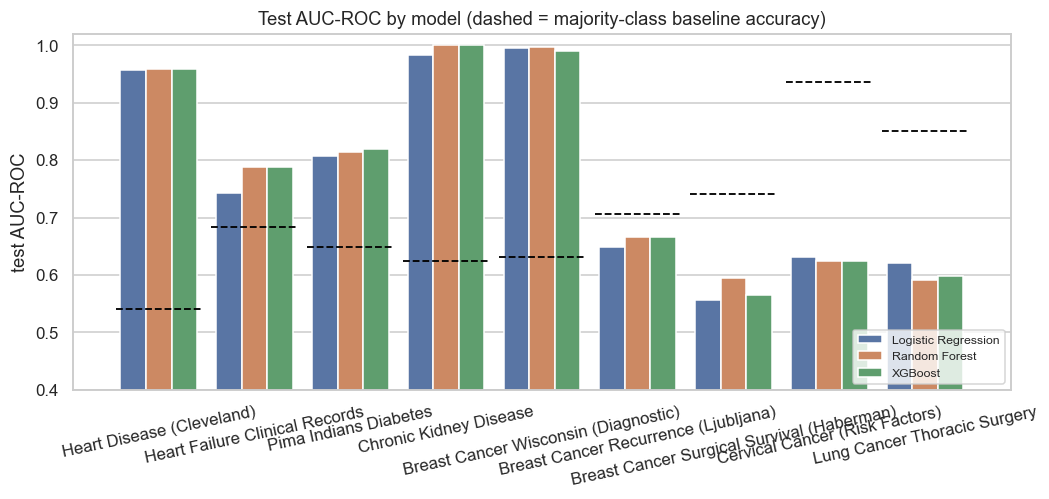

model,Logistic Regression,Random Forest,XGBoost,best_minus_logreg
dataset,,,,
Breast Cancer Recurrence (Ljubljana),0.648,0.666,0.666,0.018
Breast Cancer Surgical Survival (Haberman),0.556,0.594,0.565,0.038
Breast Cancer Wisconsin (Diagnostic),0.996,0.997,0.991,0.001
Cervical Cancer (Risk Factors),0.631,0.625,0.625,0.000
Chronic Kidney Disease,0.984,1.000,1.000,0.016
Heart Disease (Cleveland),0.958,0.959,0.959,0.001
Heart Failure Clinical Records,0.743,0.789,0.788,0.046
Lung Cancer Thoracic Surgery,0.621,0.592,0.599,0.000
Pima Indians Diabetes,0.808,0.814,0.819,0.011


Where `best_minus_logreg` is small, the transparent model is competitive and
post-hoc explanation is a convenience. Where it is large, the ensemble is
genuinely capturing interactions the additive model cannot — and that is
exactly the case where a clinician is asked to trust a black box, so SHAP
and LIME stop being optional.


In [6]:
fig, ax = plt.subplots(figsize=(11, 4.2))
sns.barplot(data=results, x="dataset", y="roc_auc", hue="model", ax=ax)
for slug, ds in schema.DATASETS.items():
    baseline = all_metrics[slug]["logistic_regression"]["majority_baseline"]
    idx = list(schema.DATASETS).index(slug)
    ax.hlines(baseline, idx - 0.45, idx + 0.45, colors="black",
              linestyles="--", linewidth=1.2)
ax.set_ylim(0.4, 1.02)
ax.set_ylabel("test AUC-ROC")
ax.set_xlabel("")
ax.set_title("Test AUC-ROC by model (dashed = majority-class baseline accuracy)")
ax.tick_params(axis="x", rotation=12)
ax.legend(title="", fontsize=8, loc="lower right")
plt.savefig(FIGURES / "03_model_comparison.png")
plt.show()

spread = (
    results.pivot_table(index="dataset", columns="model", values="roc_auc")
    .assign(best_minus_logreg=lambda d: d.max(axis=1) - d["Logistic Regression"])
    .round(3)
)
display(spread)

print(
    "Where `best_minus_logreg` is small, the transparent model is competitive and\n"
    "post-hoc explanation is a convenience. Where it is large, the ensemble is\n"
    "genuinely capturing interactions the additive model cannot — and that is\n"
    "exactly the case where a clinician is asked to trust a black box, so SHAP\n"
    "and LIME stop being optional."
)

## 3.6 Overfitting check

`gap` is train AUC minus test AUC. Small samples plus flexible ensembles make
this the failure mode to watch; a large gap means the reported test number is
fragile and the explanations describe memorised noise.

In [7]:
gaps = results.pivot_table(index="dataset", columns="model", values="gap").round(3)
display(gaps)
worst = results.loc[results["gap"].idxmax()]
print(f"Largest gap: {worst['model']} on {worst['dataset']} "
      f"({worst['gap']:.3f}) — expected, since unbounded tree depth was in the "
      f"grid and {results['dataset'].value_counts().max()} datasets are small.")

model,Logistic Regression,Random Forest,XGBoost
dataset,,,
Breast Cancer Recurrence (Ljubljana),0.096,0.179,0.205
Breast Cancer Surgical Survival (Haberman),0.187,0.299,0.318
Breast Cancer Wisconsin (Diagnostic),0.002,0.003,0.009
Cervical Cancer (Risk Factors),0.101,0.223,0.319
Chronic Kidney Disease,0.016,0.000,0.000
Heart Disease (Cleveland),-0.041,0.012,0.001
Heart Failure Clinical Records,0.082,0.210,0.139
Lung Cancer Thoracic Surgery,0.114,0.408,0.401
Pima Indians Diabetes,0.042,0.104,0.089


Largest gap: Random Forest on Lung Cancer Thoracic Surgery (0.408) — expected, since unbounded tree depth was in the grid and 3 datasets are small.


## 3.7 Persist artefacts

In [8]:
payload = {
    "random_state": RANDOM_STATE,
    "cv": "StratifiedKFold(n_splits=5, shuffle=True, random_state=42)",
    "selection_metric": "roc_auc",
    "tie_break": f"within {TIE_BAND} AUC, prefer the simpler model",
    "best_models": best_models,
    "metrics": all_metrics,
}
(ROOT / "results" / "03_metrics.json").write_text(json.dumps(payload, indent=2))
results.to_json(ROOT / "results" / "03_results_table.json", orient="records", indent=2)

print("wrote results/03_metrics.json, results/03_results_table.json")
print("\nmodels/")
for path in sorted(schema.MODELS.glob("*.pkl")):
    print(f"  {path.name:<44} {path.stat().st_size / 1024:>8.1f} KB")
print("\nNext: 04_explainability.ipynb")

wrote results/03_metrics.json, results/03_results_table.json

models/
  breast_cancer_logistic_regression.pkl             1.9 KB
  breast_cancer_logistic_regression_shap.pkl       51.4 KB
  breast_cancer_preprocessor.pkl                    4.5 KB
  breast_cancer_random_forest.pkl                2147.9 KB
  breast_cancer_random_forest_shap.pkl           3107.7 KB
  breast_cancer_recurrence_logistic_regression.pkl      1.4 KB
  breast_cancer_recurrence_logistic_regression_shap.pkl     17.4 KB
  breast_cancer_recurrence_preprocessor.pkl         2.7 KB
  breast_cancer_recurrence_random_forest.pkl      670.3 KB
  breast_cancer_recurrence_random_forest_shap.pkl    887.6 KB
  breast_cancer_recurrence_xgboost.pkl            176.9 KB
  breast_cancer_recurrence_xgboost_shap.pkl       352.6 KB
  breast_cancer_survival_logistic_regression.pkl      1.2 KB
  breast_cancer_survival_logistic_regression_shap.pkl      7.8 KB
  breast_cancer_survival_preprocessor.pkl           2.3 KB
  breast_cancer_surv